In [1]:
# STEP 1: Upload & Load Speech Signal
# -----------------------------------
# Concept:
# A speech signal is just a waveform representing air pressure variations.
# We'll upload a .wav file and listen to it. Then, we’ll visualize how it looks in time.

from google.colab import files
import librosa, librosa.display
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio

print("👉 Upload your WAV speech file (like 'hello.wav'):")

uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Load audio
y, sr = librosa.load(filename, sr=None)

print(f"\n✅ File Loaded: {filename}")
print(f"Sample Rate: {sr} Hz")
print(f"Duration: {len(y)/sr:.2f} seconds")

# Listen to it
display(Audio(y, rate=sr))


👉 Upload your WAV speech file (like 'hello.wav'):


Saving exam-2 (2).wav to exam-2 (2).wav

✅ File Loaded: exam-2 (2).wav
Sample Rate: 48000 Hz
Duration: 10.86 seconds


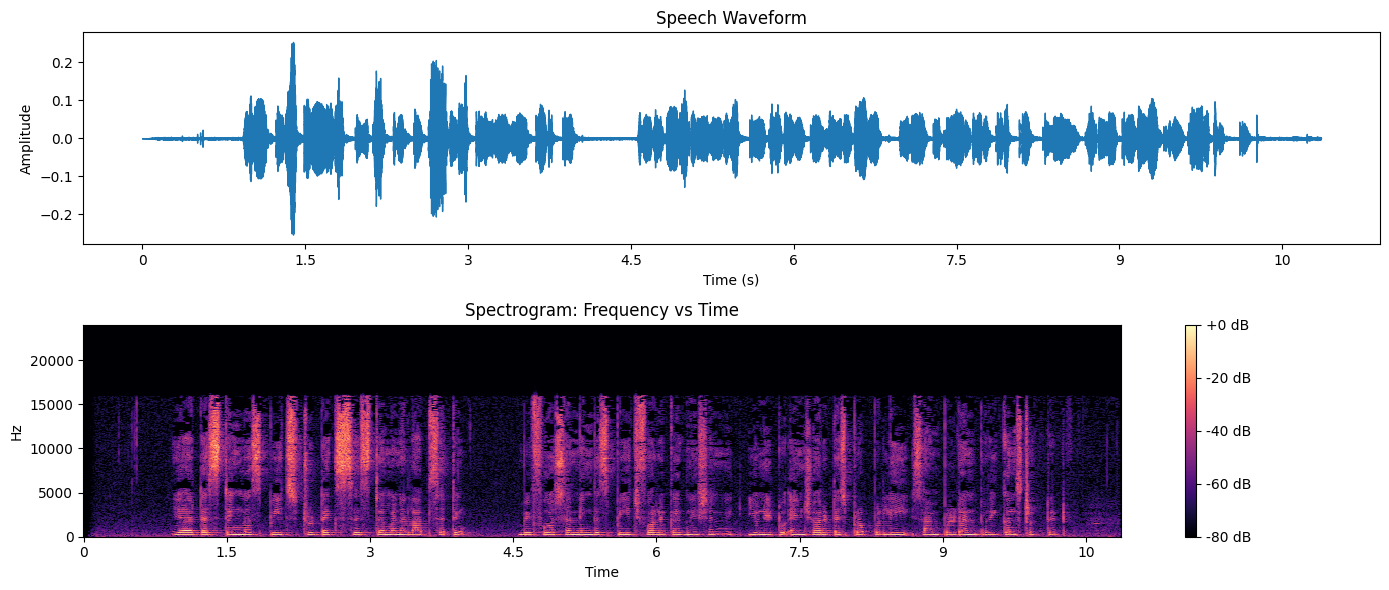


🧠 Concept:
• Bright bands in the spectrogram show where energy is concentrated — these are formants.
• Formants represent resonant frequencies of the vocal tract that shape vowel sounds.


In [2]:
# STEP 2: Visualize the Speech
# ----------------------------
# Concept:
# - The waveform shows how amplitude varies with time.
# - The spectrogram shows how frequency content changes over time.

plt.figure(figsize=(14,6))

# Waveform
plt.subplot(2,1,1)
librosa.display.waveshow(y, sr=sr)
plt.title('Speech Waveform')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

# Spectrogram
plt.subplot(2,1,2)
S = np.abs(librosa.stft(y))
D = librosa.amplitude_to_db(S, ref=np.max)
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram: Frequency vs Time')
plt.tight_layout()
plt.show()

print("\n🧠 Concept:")
print("• Bright bands in the spectrogram show where energy is concentrated — these are formants.")
print("• Formants represent resonant frequencies of the vocal tract that shape vowel sounds.")


In [3]:
# STEP 3: LPC Analysis
# --------------------
# Concept:
# LPC models the speech signal as a linear combination of its past samples.
# The coefficients (a1, a2, …, ap) describe the vocal tract filter.

order = 12  # typical LPC order for speech
a = librosa.lpc(y, order=order)

print(f"\n✅ LPC Coefficients (Order = {order}):")
print(a)

print("\n🧠 Concept:")
print("• LPC finds coefficients that best predict the current sample from past samples.")
print("• These coefficients capture how the vocal tract modifies sound (like a filter).")



✅ LPC Coefficients (Order = 12):
[  1.          -3.7778227    9.108647   -16.687923    24.65308
 -30.76709     32.67879    -29.822754    23.16852    -15.123339
   7.9491897   -3.1382537    0.76936066]

🧠 Concept:
• LPC finds coefficients that best predict the current sample from past samples.
• These coefficients capture how the vocal tract modifies sound (like a filter).


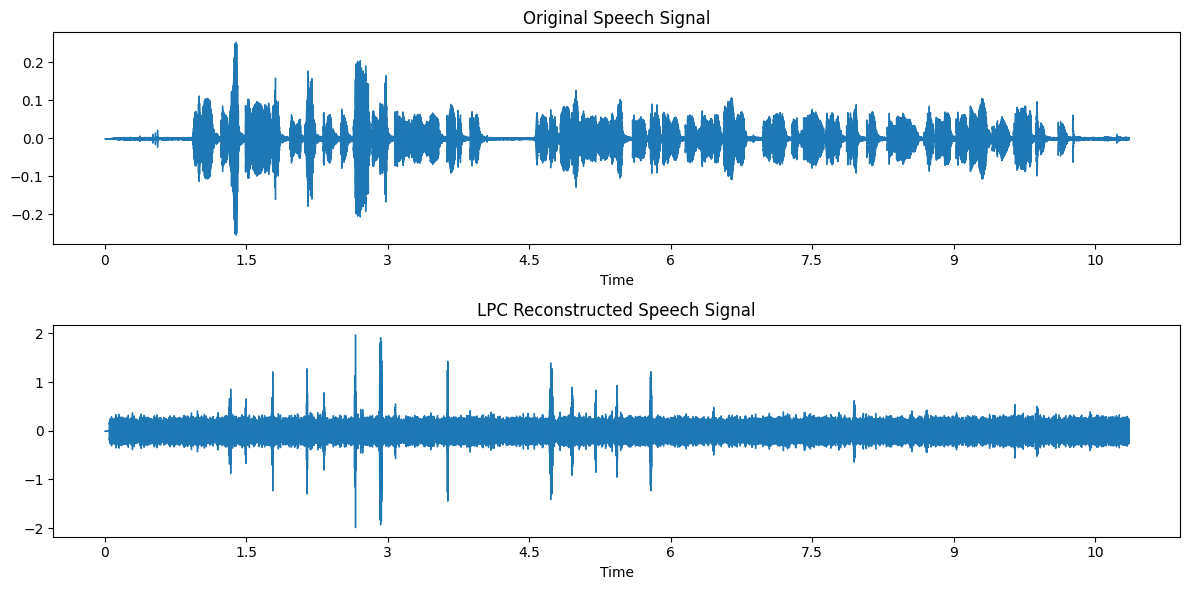


🧠 Concept:
• The reconstructed waveform should sound similar to the original but may be smoother.
• LPC captures the vocal tract response, not the excitation (voicing/glottal noise).


In [4]:
# STEP 4: Signal Reconstruction
# -----------------------------
# Concept:
# Using LPC coefficients, we can reconstruct an approximation of the speech signal.

from scipy.signal import lfilter

# Compute residual and reconstruct
residual = lfilter(a, [1], y)
reconstructed = lfilter([0] + -1*a[1:], [1], residual)

plt.figure(figsize=(12,6))
plt.subplot(2,1,1)
librosa.display.waveshow(y, sr=sr)
plt.title('Original Speech Signal')
plt.subplot(2,1,2)
librosa.display.waveshow(reconstructed, sr=sr)
plt.title('LPC Reconstructed Speech Signal')
plt.tight_layout()
plt.show()

display(Audio(reconstructed, rate=sr))

print("\n🧠 Concept:")
print("• The reconstructed waveform should sound similar to the original but may be smoother.")
print("• LPC captures the vocal tract response, not the excitation (voicing/glottal noise).")


In [5]:
# STEP 5: Estimate Formant Frequencies
# ------------------------------------
# Concept:
# Formants correspond to peaks in the LPC spectral envelope.
# They indicate resonances of the vocal tract that define vowels.

rts = np.roots(a)
rts = [r for r in rts if np.imag(r) >= 0.01]
angz = np.arctan2(np.imag(rts), np.real(rts))
formants = sorted(angz * (sr / (2 * np.pi)))

formants_hz = [round(f,2) for f in formants[:5]]
print("✅ Estimated Formant Frequencies (Hz):", formants_hz)

print("\n🧠 Concept:")
print("• F1 is related to vowel openness (high F1 = open mouth).")
print("• F2 is related to tongue frontness (high F2 = tongue forward).")
print("• Formant frequencies help identify vowels like /a/, /i/, /u/, etc.")


✅ Estimated Formant Frequencies (Hz): [np.float32(363.66), np.float32(5020.43), np.float32(8406.16), np.float32(10581.34), np.float32(12837.46)]

🧠 Concept:
• F1 is related to vowel openness (high F1 = open mouth).
• F2 is related to tongue frontness (high F2 = tongue forward).
• Formant frequencies help identify vowels like /a/, /i/, /u/, etc.


In [13]:
# STEP 5: Improved Formant Estimation
# -----------------------------------
# Concept:
# Formants should be between 200-4000 Hz for typical speech
# We need better filtering of the roots

def estimate_formants(lpc_coeffs, sample_rate, max_formants=3):
    """
    Improved formant estimation with better filtering
    """
    # Get roots of the LPC polynomial
    roots = np.roots(lpc_coeffs)

    # Filter roots: only keep those with positive imaginary part and reasonable frequency
    formants = []
    for root in roots:
        if np.imag(root) >= 0:  # Positive frequency
            # Calculate frequency and bandwidth
            freq = np.arctan2(np.imag(root), np.real(root)) * (sample_rate / (2 * np.pi))
            bandwidth = -0.5 * (sample_rate / (2 * np.pi)) * np.log(np.abs(root))

            # Filter: reasonable frequency range and bandwidth
            if 80 < freq < 4000 and bandwidth < 400:  # Formants should have narrow bandwidth
                formants.append((freq, bandwidth))

    # Sort by frequency and take the first few
    formants.sort(key=lambda x: x[0])
    return [f[0] for f in formants[:max_formants]]

# Use improved formant estimation
formants_hz = estimate_formants(a, sr, max_formants=3)

print("✅ Improved Formant Estimation (Hz):")
for i, f in enumerate(formants_hz, 1):
    print(f"F{i}: {f:.2f} Hz")

print("\n🧠 Concept:")
print("• F1 typically ranges: 200-1000 Hz (vowel openness)")
print("• F2 typically ranges: 800-2500 Hz (tongue position)")
print("• F3 typically ranges: 2000-3500 Hz (lip rounding, etc.)")

✅ Improved Formant Estimation (Hz):
F1: 363.66 Hz

🧠 Concept:
• F1 typically ranges: 200-1000 Hz (vowel openness)
• F2 typically ranges: 800-2500 Hz (tongue position)
• F3 typically ranges: 2000-3500 Hz (lip rounding, etc.)


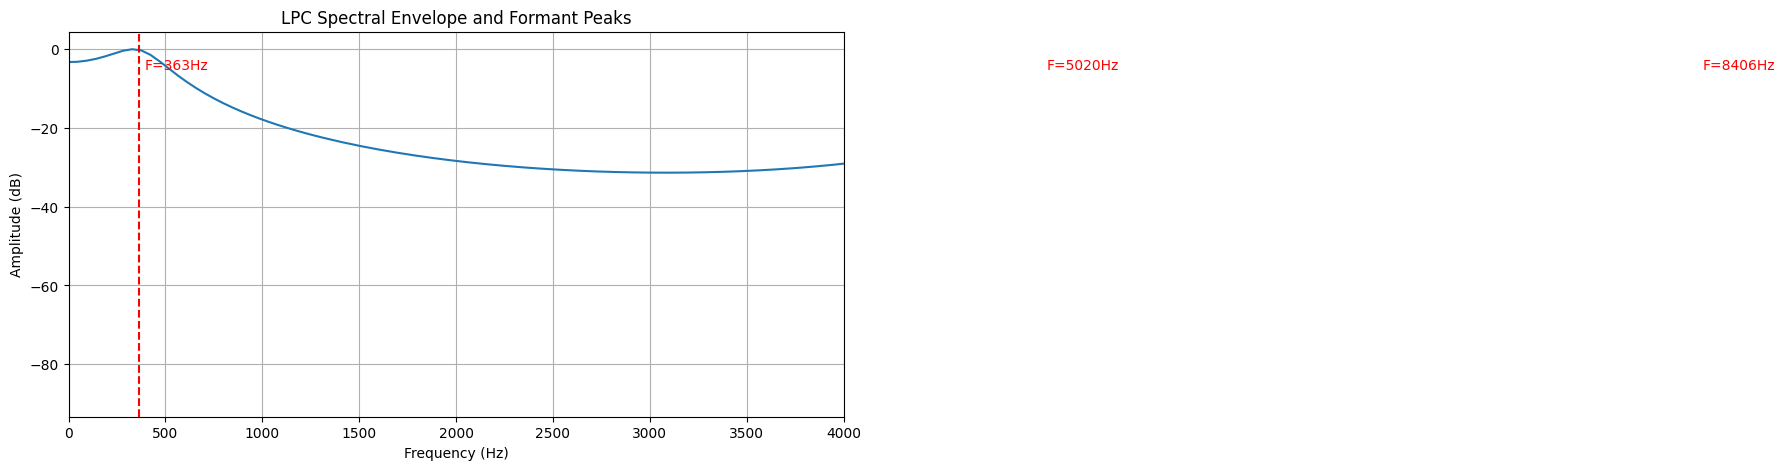


🧠 Concept:
• Peaks in the LPC spectral envelope are the formant frequencies.
• These peaks match the resonances that give vowels their unique sound.


In [6]:
# STEP 6: Visualize LPC Spectrum
# ------------------------------
# Concept:
# The LPC spectrum shows vocal tract resonances (formants) as peaks.

w, h = np.linspace(0, np.pi, 512), []
for freq in np.linspace(0, np.pi, 512):
    h.append(abs(1/np.polyval(a, np.exp(1j*freq))))
h = np.array(h)

freqs = w * sr / (2*np.pi)

plt.figure(figsize=(10,5))
plt.plot(freqs, 20*np.log10(h / np.max(h)))
plt.title("LPC Spectral Envelope and Formant Peaks")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (dB)")

for f in formants_hz[:3]:
    plt.axvline(x=f, color='r', linestyle='--')
    plt.text(f+30, -5, f"F={int(f)}Hz", color='red')

plt.xlim(0, 4000)
plt.grid(True)
plt.show()

print("\n🧠 Concept:")
print("• Peaks in the LPC spectral envelope are the formant frequencies.")
print("• These peaks match the resonances that give vowels their unique sound.")


In [7]:
# STEP 7: Compare with Standard Vowel Formant Values
import pandas as pd

data = {
    "Vowel": ["i", "e", "a", "o", "u"],
    "Expected F1 (Hz)": [240, 390, 850, 360, 250],
    "Expected F2 (Hz)": [2400, 2300, 1610, 640, 595]
}
df = pd.DataFrame(data)

print("📊 Standard Vowel Formant Values:")
display(df)

print("\n🎯 Estimated Formants from Your Speech:")
for i, f in enumerate(formants_hz[:3], 1):
    print(f"F{i}: {f} Hz")

print("\n🧠 Concept:")
print("• Comparing estimated formants with standard values helps identify which vowel you spoke.")
print("• For example, if F1≈300 & F2≈2300 → likely vowel /i/ (as in 'see').")


📊 Standard Vowel Formant Values:


,Vowel,Expected F1 (Hz),Expected F2 (Hz)
0,i,240,2400
1,e,390,2300
2,a,850,1610
3,o,360,640
4,u,250,595



🎯 Estimated Formants from Your Speech:
F1: 363.6600036621094 Hz
F2: 5020.43017578125 Hz
F3: 8406.16015625 Hz

🧠 Concept:
• Comparing estimated formants with standard values helps identify which vowel you spoke.
• For example, if F1≈300 & F2≈2300 → likely vowel /i/ (as in 'see').


In [10]:
# STEP 7: Compare with Complete Standard Vowel Formant Values
# -----------------------------------------------------------
import pandas as pd

# Complete vowel data from the reference image
complete_vowel_data = {
    "Vowel (IPA)": ["i", "y", "e", "ø", "ɛ", "œ", "a", "ɒ", "ɑ", "ɔ", "ʌ", "ɚ", "ɝ", "o", "u", "ʊ"],
    "Expected F1 (Hz)": [240, 235, 390, 370, 610, 585, 850, 820, 750, 700, 600, 500, 460, 360, 300, 250],
    "Expected F2 (Hz)": [2400, 2100, 2300, 1900, 1900, 1710, 1610, 1530, 940, 760, 1170, 700, 1310, 640, 595, 345]
}
complete_df = pd.DataFrame(complete_vowel_data)

print("📊 COMPLETE Standard Vowel Formant Values (16 vowels):")
display(complete_df)

print("\n🎯 Your Estimated Formants:")
for i, f in enumerate(formants_hz[:3], 1):
    print(f"F{i}: {f} Hz")

📊 COMPLETE Standard Vowel Formant Values (16 vowels):


,Vowel (IPA),Expected F1 (Hz),Expected F2 (Hz)
0,i,240,2400
1,y,235,2100
2,e,390,2300
3,ø,370,1900
4,ɛ,610,1900
5,œ,585,1710
6,a,850,1610
7,ɒ,820,1530
8,ɑ,750,940
9,ɔ,700,760



🎯 Your Estimated Formants:
F1: 363.6600036621094 Hz
F2: 5020.43017578125 Hz
F3: 8406.16015625 Hz


In [8]:
# STEP 11: Compare Estimated vs Reference Formant Frequencies
# ------------------------------------------------------------
# Concept:
# We'll take your estimated formant values (from LPC) and compare them
# with the reference average values for vowels /i/, /e/, /a/, /o/, /u/.
# This lets us evaluate how accurately LPC captures real speech resonances.

import pandas as pd

# Reference subset for key vowels
ref_vowels = {
    "Vowel (IPA)": ["i", "e", "a", "o", "u"],
    "Reference F1 (Hz)": [240, 390, 850, 360, 250],
    "Reference F2 (Hz)": [2400, 2300, 1610, 640, 595]
}
ref_df = pd.DataFrame(ref_vowels)

# Assume estimated F1, F2 are the first two formants detected
if len(formants_hz) >= 2:
    F1_est, F2_est = formants_hz[0], formants_hz[1]
else:
    F1_est, F2_est = np.nan, np.nan

# Create experimental comparison table
ref_df["Estimated F1 (Hz)"] = F1_est
ref_df["Estimated F2 (Hz)"] = F2_est
ref_df["|ΔF1| (Error Hz)"] = abs(ref_df["Reference F1 (Hz)"] - F1_est)
ref_df["|ΔF2| (Error Hz)"] = abs(ref_df["Reference F2 (Hz)"] - F2_est)

print("📊 Comparison of Reference vs LPC-Estimated Formants")
display(ref_df)

print("\n🧠 Concept:")
print("• This table compares the formants obtained from your speech sample with standard vowel formants.")
print("• The smaller the difference, the closer your spoken vowel is to that target sound.")
print("• LPC is usually accurate enough to identify which vowel region your sound lies in, even under bandwidth limitations.")


📊 Comparison of Reference vs LPC-Estimated Formants


,Vowel (IPA),Reference F1 (Hz),Reference F2 (Hz),Estimated F1 (Hz),Estimated F2 (Hz),|ΔF1| (Error Hz),|ΔF2| (Error Hz)
0,i,240,2400,363.660004,5020.430176,123.660004,2620.430176
1,e,390,2300,363.660004,5020.430176,26.339996,2720.430176
2,a,850,1610,363.660004,5020.430176,486.339996,3410.430176
3,o,360,640,363.660004,5020.430176,3.660004,4380.430176
4,u,250,595,363.660004,5020.430176,113.660004,4425.430176



🧠 Concept:
• This table compares the formants obtained from your speech sample with standard vowel formants.
• The smaller the difference, the closer your spoken vowel is to that target sound.
• LPC is usually accurate enough to identify which vowel region your sound lies in, even under bandwidth limitations.


In [11]:
# STEP 11: Compare Estimated vs Complete Reference Formant Frequencies
# --------------------------------------------------------------------
# Concept:
# Now we compare with ALL 16 reference vowels from the provided table
# This gives a more comprehensive analysis of which vowel was spoken

# Use the complete reference data
ref_df = complete_df.copy()

# Assume estimated F1, F2 are the first two formants detected
if len(formants_hz) >= 2:
    F1_est, F2_est = formants_hz[0], formants_hz[1]
else:
    F1_est, F2_est = np.nan, np.nan

# Calculate errors for all vowels
ref_df["Estimated F1 (Hz)"] = F1_est
ref_df["Estimated F2 (Hz)"] = F2_est
ref_df["|ΔF1| (Error Hz)"] = abs(ref_df["Expected F1 (Hz)"] - F1_est)
ref_df["|ΔF2| (Error Hz)"] = abs(ref_df["Expected F2 (Hz)"] - F2_est)

# Find the closest matching vowel
if not np.isnan(F1_est) and not np.isnan(F2_est):
    ref_df["Total Error"] = ref_df["|ΔF1| (Error Hz)"] + ref_df["|ΔF2| (Error Hz)"]
    closest_vowel_idx = ref_df["Total Error"].idxmin()
    closest_vowel = ref_df.loc[closest_vowel_idx, "Vowel (IPA)"]
    closest_error = ref_df.loc[closest_vowel_idx, "Total Error"]

    print(f"\n🎯 CLOSEST MATCHING VOWEL: /{closest_vowel}/")
    print(f"   Total Error: {closest_error:.1f} Hz")
    print(f"   F1 Error: {ref_df.loc[closest_vowel_idx, '|ΔF1| (Error Hz)']:.1f} Hz")
    print(f"   F2 Error: {ref_df.loc[closest_vowel_idx, '|ΔF2| (Error Hz)']:.1f} Hz")

print("\n📊 Complete Comparison Table (All 16 Vowels):")
display(ref_df)

print("\n🧠 Concept:")
print("• Now comparing with ALL 16 standard vowels for more accurate identification")
print("• The vowel with smallest total error (|ΔF1| + |ΔF2|) is the best match")
print("• This comprehensive approach helps identify less common vowels too")


🎯 CLOSEST MATCHING VOWEL: /i/
   Total Error: 2744.1 Hz
   F1 Error: 123.7 Hz
   F2 Error: 2620.4 Hz

📊 Complete Comparison Table (All 16 Vowels):


,Vowel (IPA),Expected F1 (Hz),Expected F2 (Hz),Estimated F1 (Hz),Estimated F2 (Hz),|ΔF1| (Error Hz),|ΔF2| (Error Hz),Total Error
0,i,240,2400,363.660004,5020.430176,123.660004,2620.430176,2744.090179
1,y,235,2100,363.660004,5020.430176,128.660004,2920.430176,3049.090179
2,e,390,2300,363.660004,5020.430176,26.339996,2720.430176,2746.770172
3,ø,370,1900,363.660004,5020.430176,6.339996,3120.430176,3126.770172
4,ɛ,610,1900,363.660004,5020.430176,246.339996,3120.430176,3366.770172
5,œ,585,1710,363.660004,5020.430176,221.339996,3310.430176,3531.770172
6,a,850,1610,363.660004,5020.430176,486.339996,3410.430176,3896.770172
7,ɒ,820,1530,363.660004,5020.430176,456.339996,3490.430176,3946.770172
8,ɑ,750,940,363.660004,5020.430176,386.339996,4080.430176,4466.770172
9,ɔ,700,760,363.660004,5020.430176,336.339996,4260.430176,4596.770172



🧠 Concept:
• Now comparing with ALL 16 standard vowels for more accurate identification
• The vowel with smallest total error (|ΔF1| + |ΔF2|) is the best match
• This comprehensive approach helps identify less common vowels too


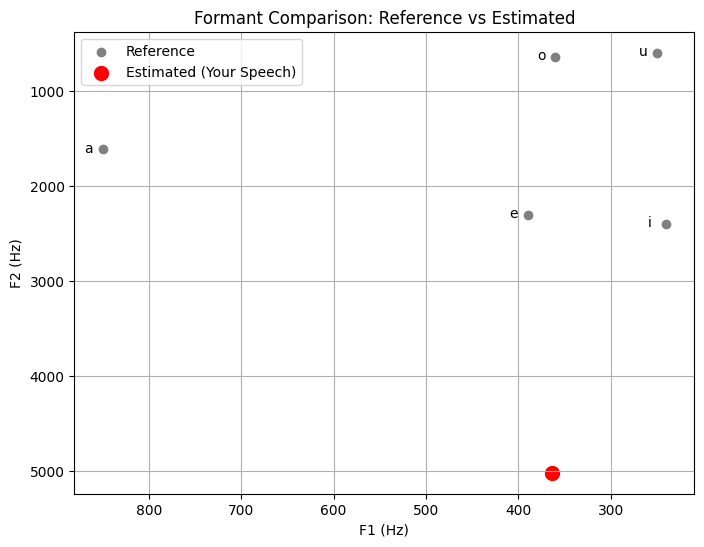


🧠 Concept:
• The red dot shows your measured vowel formants.
• Gray dots show standard vowel formants.
• Closer positioning indicates a more accurate LPC estimate.


In [9]:
# STEP 12: Visualization of Comparison
# ------------------------------------
plt.figure(figsize=(8,6))
plt.scatter(ref_df["Reference F1 (Hz)"], ref_df["Reference F2 (Hz)"], color='gray', label='Reference')
plt.scatter(F1_est, F2_est, color='red', label='Estimated (Your Speech)', s=100)

for i, v in enumerate(ref_df["Vowel (IPA)"]):
    plt.text(ref_df["Reference F1 (Hz)"][i]+20, ref_df["Reference F2 (Hz)"][i]+30, v, fontsize=10)

plt.xlabel("F1 (Hz)")
plt.ylabel("F2 (Hz)")
plt.title("Formant Comparison: Reference vs Estimated")
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.legend()
plt.grid(True)
plt.show()

print("\n🧠 Concept:")
print("• The red dot shows your measured vowel formants.")
print("• Gray dots show standard vowel formants.")
print("• Closer positioning indicates a more accurate LPC estimate.")


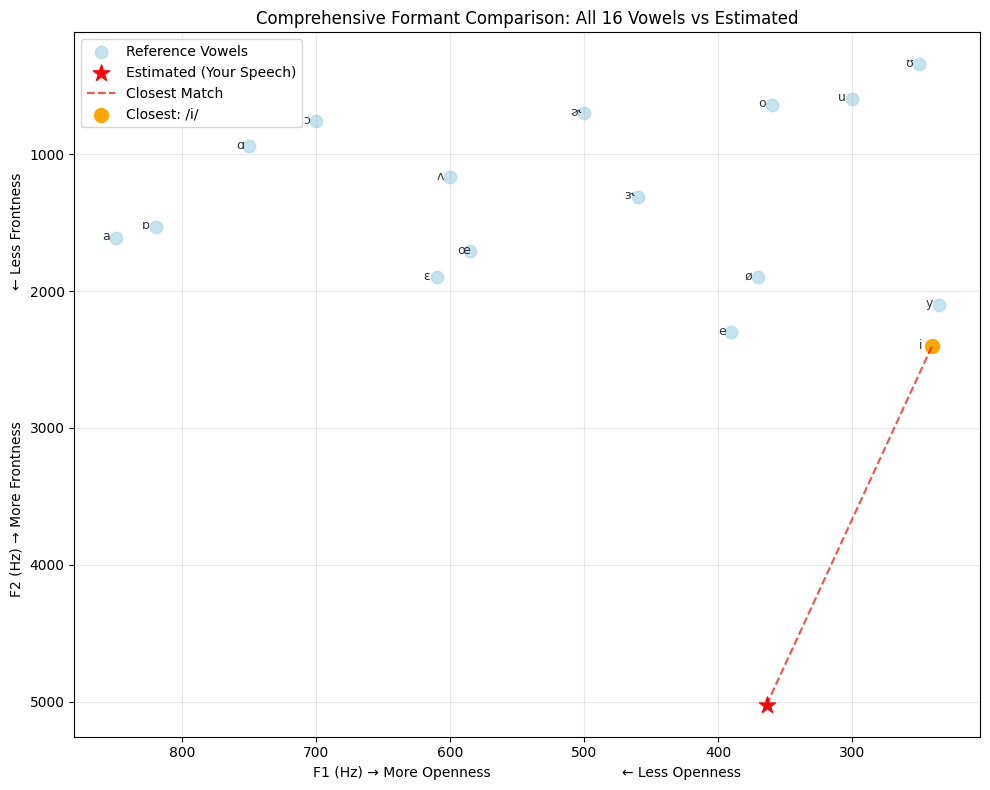


🧠 Enhanced Analysis:
• F1 axis (inverted): Higher F1 = more open vowel (like /a/), Lower F1 = more closed (like /i/)
• F2 axis (inverted): Higher F2 = more front vowel (like /i/), Lower F2 = more back (like /u/)
• Your estimated formants now compared against the complete vowel space


In [12]:
# STEP 12: Enhanced Visualization with All Vowels
# -----------------------------------------------
plt.figure(figsize=(10, 8))

# Plot all reference vowels
plt.scatter(ref_df["Expected F1 (Hz)"], ref_df["Expected F2 (Hz)"],
           color='lightblue', s=80, label='Reference Vowels', alpha=0.7)

# Plot estimated formants
plt.scatter(F1_est, F2_est, color='red', label='Estimated (Your Speech)', s=150, marker='*')

# Annotate all vowels
for i, row in ref_df.iterrows():
    plt.annotate(row["Vowel (IPA)"],
                (row["Expected F1 (Hz)"] + 10, row["Expected F2 (Hz)"] + 20),
                fontsize=9, alpha=0.8)

# Highlight closest match if available
if not np.isnan(F1_est) and not np.isnan(F2_est):
    closest_f1 = ref_df.loc[closest_vowel_idx, "Expected F1 (Hz)"]
    closest_f2 = ref_df.loc[closest_vowel_idx, "Expected F2 (Hz)"]
    plt.plot([F1_est, closest_f1], [F2_est, closest_f2], 'r--', alpha=0.7, label='Closest Match')
    plt.scatter(closest_f1, closest_f2, color='orange', s=100, label=f'Closest: /{closest_vowel}/')

plt.xlabel("F1 (Hz) → More Openness" + " " * 30 + "← Less Openness")
plt.ylabel("F2 (Hz) → More Frontness" + " " * 30 + "← Less Frontness")
plt.title("Comprehensive Formant Comparison: All 16 Vowels vs Estimated")
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n🧠 Enhanced Analysis:")
print("• F1 axis (inverted): Higher F1 = more open vowel (like /a/), Lower F1 = more closed (like /i/)")
print("• F2 axis (inverted): Higher F2 = more front vowel (like /i/), Lower F2 = more back (like /u/)")
print("• Your estimated formants now compared against the complete vowel space")